In [1]:
import pandas as pd
from os import listdir, path
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


# Task 1
Assume we are running an A/B test on a difficulty flow, and each variant receives
exactly 20,000 installs per day. Write the codes to analyze and create graphics.

In [2]:
variant_a_given_data = {
    "dpr": 0.0305,
    "ecpm": 9.80,
    "imp_per_dau": 2.3,
    "d1_ret": 0.53,
    "d3_ret": 0.27,
    "d7_ret": 0.17,
    "d14_ret": 0.06,
}
variant_b_given_data = {
    "dpr": 0.0315,
    "ecpm": 10.80,
    "imp_per_dau": 1.6,
    "d1_ret": 0.48,
    "d3_ret": 0.25,
    "d7_ret": 0.19,
    "d14_ret": 0.09,

}
simulation_length = 120

### a) Which variant will have the **most daily active users** after 15 days?
For this part I will first interpolate the retentions and then take calculate DAU for each day according to this interpolation.

In [3]:
# Sample known retention data 
variant_a_data = {'day': [1, 3, 7, 14], 'retention': [
    variant_a_given_data["d1_ret"],
    variant_a_given_data["d3_ret"],
    variant_a_given_data["d7_ret"],
    variant_a_given_data["d14_ret"],
]}
variant_a_df_retention = pd.DataFrame(variant_a_data)
variant_b_data = {'day': [1, 3, 7, 14], 'retention': [
    variant_b_given_data["d1_ret"],
    variant_b_given_data["d3_ret"],
    variant_b_given_data["d7_ret"],
    variant_b_given_data["d14_ret"],
]}
variant_b_df_retention = pd.DataFrame(variant_b_data)

# Define Power Law function: R(n) = a * n^b 
# Source for the method https://www.linkedin.com/pulse/retention-curves-heuristic-approach-russell-ovans-f15qc
def power_law(n, a, b):
    return a * np.power(n, b)

# Fit the curve
popt_variant_a, pcov_variant_a = curve_fit(power_law, variant_a_df_retention['day'], variant_a_df_retention['retention'])
a_fit_variant_a, b_fit_variant_a = popt_variant_a

popt_variant_b, pcov_variant_b = curve_fit(power_law, variant_b_df_retention['day'], variant_b_df_retention['retention'])
a_fit_variant_b, b_fit_variant_b = popt_variant_b

# Predict retention for missing days (e.g., up to simulation_length0)
all_days = pd.DataFrame({'day': np.arange(1, simulation_length)})
all_days['predicted_retention_variant_a'] = power_law(all_days['day'], a_fit_variant_a, b_fit_variant_a)
all_days['predicted_retention_variant_b'] = power_law(all_days['day'], a_fit_variant_b, b_fit_variant_b)


In [4]:
all_days.head()

,day,predicted_retention_variant_a,predicted_retention_variant_b
0,1,0.534276,0.479299
1,2,0.339390,0.325853
2,3,0.260270,0.260010
3,4,0.215592,0.221532
4,5,0.186291,0.195653


In [5]:
daily_sim = pd.DataFrame({'day': np.arange(1, simulation_length)})
daily_sim['installs'] = 20000

daily_sim['dau_a'] = np.convolve(
    daily_sim['installs'],
    np.r_[1.0 , all_days['predicted_retention_variant_a']]
)[:len(daily_sim)].astype(int)

daily_sim['dau_b'] = np.convolve(
    daily_sim['installs'],
    np.r_[1.0 , all_days['predicted_retention_variant_b']]
)[:len(daily_sim)].astype(int)

daily_sim = daily_sim.set_index('day')

Text(0, 0.5, 'B - A')

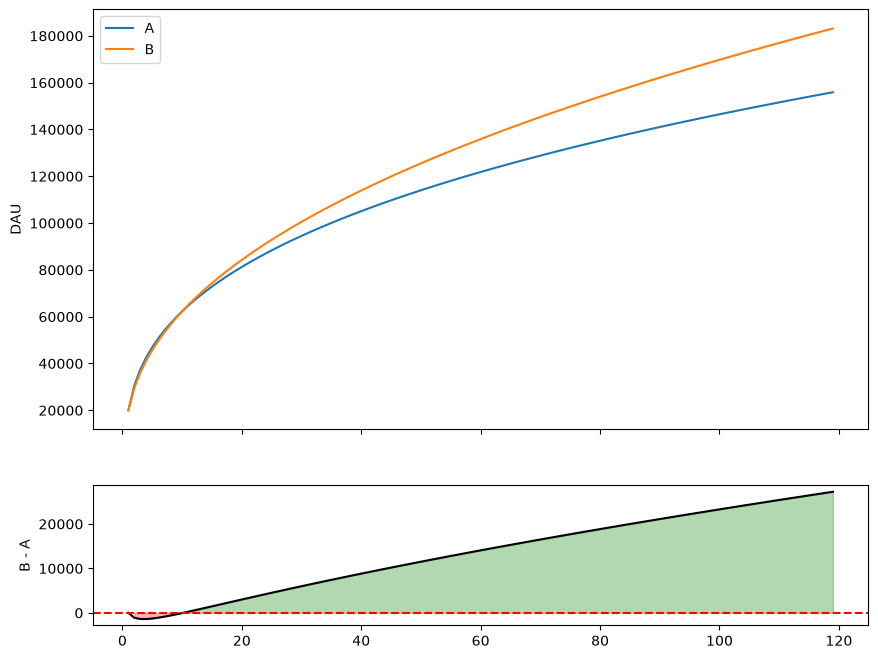

In [6]:
# AI assisted charts:
daily_sim["diff"] = daily_sim["dau_b"] - daily_sim["dau_a"]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Original DAU
ax1.plot(daily_sim.index, daily_sim["dau_a"], label="A")
ax1.plot(daily_sim.index, daily_sim["dau_b"], label="B")
ax1.legend()
ax1.set_ylabel("DAU")

# Difference
ax2.plot(daily_sim.index, daily_sim["diff"], color="black")
ax2.axhline(0, color="red", linestyle="--")
ax2.fill_between(
    daily_sim.index,
    daily_sim["diff"],
    0,
    where=daily_sim["diff"] > 0,
    alpha=0.3,
    color="green"
)
ax2.fill_between(
    daily_sim.index,
    daily_sim["diff"],
    0,
    where=daily_sim["diff"] < 0,
    alpha=0.3,
    color="red"
)

ax2.set_ylabel("B - A")

In [7]:
daily_sim.loc[15]

installs    20000
dau_a       72870
dau_b       74351
diff         1481
Name: 15, dtype: int64

According to above results Variant B will have more users than Variant B by the day 15.

### b) Which variant will earn the **most total money** by Day 15?
I will use the same DAU data from the previous part and calculate daily revenue by using other monetization metrics.

In [8]:
daily_sim["ecpm_a"] = variant_a_given_data["ecpm"]
daily_sim["imp_per_dau_a"] = variant_a_given_data["imp_per_dau"]
daily_sim["dpr_a"] = variant_a_given_data["dpr"]
daily_sim["ecpm_b"] = variant_b_given_data["ecpm"]
daily_sim["imp_per_dau_b"] = variant_b_given_data["imp_per_dau"]
daily_sim["dpr_b"] = variant_b_given_data["dpr"]

In [9]:
daily_sim["ad_rev_a"] = daily_sim["dau_a"] * daily_sim["imp_per_dau_a"] * daily_sim["ecpm_a"] / 1000
daily_sim["ad_rev_b"] = daily_sim["dau_b"] * daily_sim["imp_per_dau_b"] * daily_sim["ecpm_b"] / 1000
# I'm assuming dpr * dau gives IAP revenue
daily_sim["iap_rev_a"] = daily_sim["dau_a"] * daily_sim["dpr_a"]
daily_sim["iap_rev_b"] = daily_sim["dau_b"] * daily_sim["dpr_b"]

daily_sim["rev_a"] = daily_sim["ad_rev_a"] + daily_sim["iap_rev_a"]
daily_sim["rev_b"] = daily_sim["ad_rev_b"] + daily_sim["iap_rev_b"]
daily_sim["cumulative_rev_a"] = daily_sim["rev_a"].cumsum()
daily_sim["cumulative_rev_b"] = daily_sim["rev_b"].cumsum()

In [10]:
daily_sim.head()

,installs,dau_a,dau_b,diff,ecpm_a,imp_per_dau_a,dpr_a,ecpm_b,imp_per_dau_b,dpr_b,ad_rev_a,ad_rev_b,iap_rev_a,iap_rev_b,rev_a,rev_b,cumulative_rev_a,cumulative_rev_b
day,,,,,,,,,,,,,,,,,,
1,20000,20000,20000,0,9.8,2.3,0.0305,10.8,1.6,0.0315,450.80000,345.60000,610.0000,630.0000,1060.80000,975.60000,1060.80000,975.60000
2,20000,30685,29585,-1100,9.8,2.3,0.0305,10.8,1.6,0.0315,691.63990,511.22880,935.8925,931.9275,1627.53240,1443.15630,2688.33240,2418.75630
3,20000,37473,36103,-1370,9.8,2.3,0.0305,10.8,1.6,0.0315,844.64142,623.85984,1142.9265,1137.2445,1987.56792,1761.10434,4675.90032,4179.86064
4,20000,42678,41303,-1375,9.8,2.3,0.0305,10.8,1.6,0.0315,961.96212,713.71584,1301.6790,1301.0445,2263.64112,2014.76034,6939.54144,6194.62098
5,20000,46990,45733,-1257,9.8,2.3,0.0305,10.8,1.6,0.0315,1059.15460,790.26624,1433.1950,1440.5895,2492.34960,2230.85574,9431.89104,8425.47672


Text(0, 0.5, 'B - A')

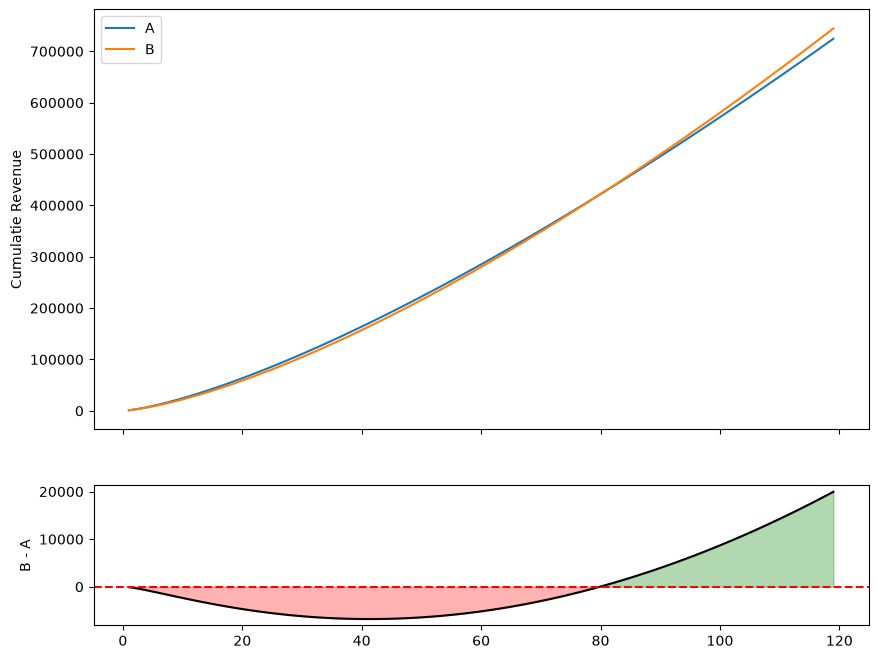

In [11]:
daily_sim["rev_diff"] = daily_sim["cumulative_rev_b"] - daily_sim["cumulative_rev_a"]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Original Cumulative Rev
ax1.plot(daily_sim.index, daily_sim["cumulative_rev_a"], label="A")
ax1.plot(daily_sim.index, daily_sim["cumulative_rev_b"], label="B")
ax1.legend()
ax1.set_ylabel("Cumulatie Revenue")

# Difference
ax2.plot(daily_sim.index, daily_sim["rev_diff"], color="black")
ax2.axhline(0, color="red", linestyle="--")
ax2.fill_between(
    daily_sim.index,
    daily_sim["rev_diff"],
    0,
    where=daily_sim["rev_diff"] > 0,
    alpha=0.3,
    color="green"
)
ax2.fill_between(
    daily_sim.index,
    daily_sim["rev_diff"],
    0,
    where=daily_sim["rev_diff"] < 0,
    alpha=0.3,
    color="red"
)

ax2.set_ylabel("B - A")

In [12]:
daily_sim[["cumulative_rev_a", "cumulative_rev_b"]].loc[15]

cumulative_rev_a    42748.27752
cumulative_rev_b    39140.19396
Name: 15, dtype: float64

Above results show Variant A earned more money by the test day 30.

### c) If we look at the **total money earned by Day 30** instead, does our choice change?


In [13]:
daily_sim[["cumulative_rev_a", "cumulative_rev_b"]].loc[30]

cumulative_rev_a    110571.05592
cumulative_rev_b    104381.59032
Name: 30, dtype: float64

No It doesn't change our choice, still Variant A has better monetization.

### d) What if we run a 10-day sale starting on Day 15 (boosting everyone's purchase rate by 1%)? Does this change which variant earns more **total money by Day 30**?

(I'm assuming Daily Purchase Ratios for Variant A goes from `0.0305` to `0.0405`. Not a 1% increase like `0.030805`)

In [14]:
daily_sim["dpr_a_sale"] = daily_sim["dpr_a"] 
daily_sim.loc[15:24 , "dpr_a_sale"] = daily_sim.loc[15:24]["dpr_a_sale"] + 0.01
daily_sim["dpr_b_sale"] = daily_sim["dpr_b"] 
daily_sim.loc[15:24 , "dpr_b_sale"] = daily_sim.loc[15:24]["dpr_b_sale"] + 0.01 
# I'm assuming dpr * dau gives IAP revenue
daily_sim["iap_rev_a_sale"] = daily_sim["dau_a"] * daily_sim["dpr_a_sale"]
daily_sim["iap_rev_b_sale"] = daily_sim["dau_b"] * daily_sim["dpr_b_sale"]
daily_sim["rev_a_sale"] = daily_sim["ad_rev_a"] + daily_sim["iap_rev_a_sale"]
daily_sim["rev_b_sale"] = daily_sim["ad_rev_b"] + daily_sim["iap_rev_b_sale"]
daily_sim["cumulative_rev_a_sale"] = daily_sim["rev_a_sale"].cumsum()
daily_sim["cumulative_rev_b_sale"] = daily_sim["rev_b_sale"].cumsum()
daily_sim.head()

,installs,dau_a,dau_b,diff,ecpm_a,imp_per_dau_a,dpr_a,ecpm_b,imp_per_dau_b,dpr_b,...,cumulative_rev_b,rev_diff,dpr_a_sale,dpr_b_sale,iap_rev_a_sale,iap_rev_b_sale,rev_a_sale,rev_b_sale,cumulative_rev_a_sale,cumulative_rev_b_sale
day,,,,,,,,,,,,,,,,,,,,,
1,20000,20000,20000,0,9.8,2.3,0.0305,10.8,1.6,0.0315,...,975.60000,-85.20000,0.0305,0.0315,610.0000,630.0000,1060.80000,975.60000,1060.80000,975.60000
2,20000,30685,29585,-1100,9.8,2.3,0.0305,10.8,1.6,0.0315,...,2418.75630,-269.57610,0.0305,0.0315,935.8925,931.9275,1627.53240,1443.15630,2688.33240,2418.75630
3,20000,37473,36103,-1370,9.8,2.3,0.0305,10.8,1.6,0.0315,...,4179.86064,-496.03968,0.0305,0.0315,1142.9265,1137.2445,1987.56792,1761.10434,4675.90032,4179.86064
4,20000,42678,41303,-1375,9.8,2.3,0.0305,10.8,1.6,0.0315,...,6194.62098,-744.92046,0.0305,0.0315,1301.6790,1301.0445,2263.64112,2014.76034,6939.54144,6194.62098
5,20000,46990,45733,-1257,9.8,2.3,0.0305,10.8,1.6,0.0315,...,8425.47672,-1006.41432,0.0305,0.0315,1433.1950,1440.5895,2492.34960,2230.85574,9431.89104,8425.47672


Text(0, 0.5, 'B - A')

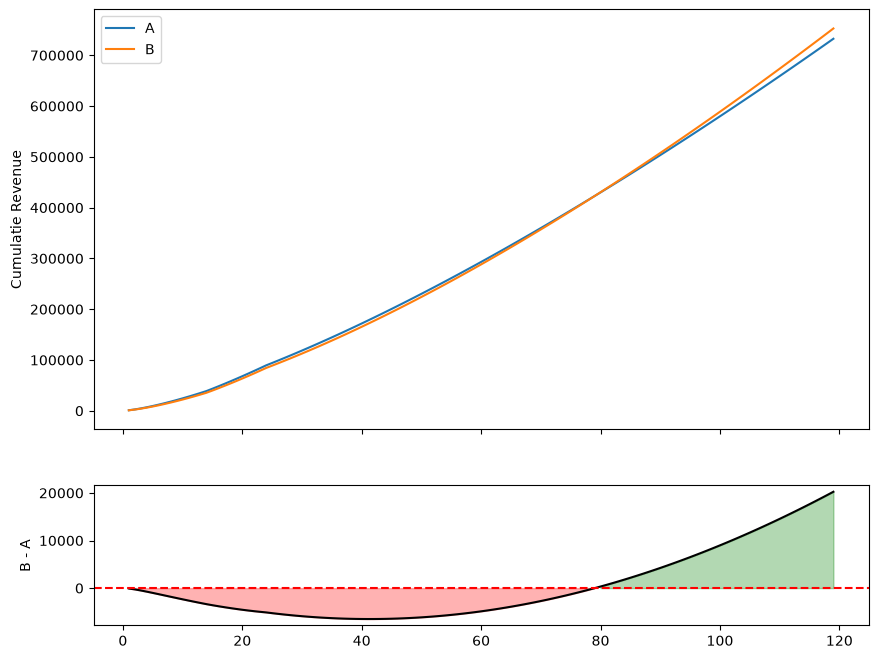

In [15]:
daily_sim["rev_diff_sale"] = daily_sim["cumulative_rev_b_sale"] - daily_sim["cumulative_rev_a_sale"]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Original Cumulative Rev
ax1.plot(daily_sim.index, daily_sim["cumulative_rev_a_sale"], label="A")
ax1.plot(daily_sim.index, daily_sim["cumulative_rev_b_sale"], label="B")
ax1.legend()
ax1.set_ylabel("Cumulatie Revenue")

# Difference
ax2.plot(daily_sim.index, daily_sim["rev_diff_sale"], color="black")
ax2.axhline(0, color="red", linestyle="--")
ax2.fill_between(
    daily_sim.index,
    daily_sim["rev_diff_sale"],
    0,
    where=daily_sim["rev_diff_sale"] > 0,
    alpha=0.3,
    color="green"
)
ax2.fill_between(
    daily_sim.index,
    daily_sim["rev_diff_sale"],
    0,
    where=daily_sim["rev_diff_sale"] < 0,
    alpha=0.3,
    color="red"
)

ax2.set_ylabel("B - A")

In [16]:
daily_sim.loc[30, ["cumulative_rev_a_sale", "cumulative_rev_b_sale"]]

cumulative_rev_a_sale    118597.82592
cumulative_rev_b_sale    112694.44032
Name: 30, dtype: float64

This still doesn't change the result, Variant A is better. (TODO: This suggests me that the that my IAP revenue calculation is wrong.)

### e) On Day 20 we add a new user source. From then on, we get 12,000 users from the original source and 8,000 from this new one. The new users' retention is described by these formulas. With this mix of old and new users, which variant makes more **total money by Day 30**?
● Variant A (New): $Retention = 0.58 \cdot e^{-0.12(x-1)}$

● Variant B (New): $Retention = 0.52 \cdot e^{-0.10(x-1)}$

In [17]:
def new_ret_func(day, base, power):
    return base*np.power(np.e, power*(day-1))

In [18]:

daily_sim["variant_a_new_source_retention"] = daily_sim.index.to_series().apply(new_ret_func, base=0.58, power=-0.12)
daily_sim["variant_b_new_source_retention"] = daily_sim.index.to_series().apply(new_ret_func, base=0.52, power=-0.10)
daily_sim["old_installs_a"] = 12000
daily_sim["old_installs_b"] = 12000
daily_sim["new_installs_a"] = 8000
daily_sim["new_installs_b"] = 8000
daily_sim.loc[:19,"old_installs_a"] = 20000
daily_sim.loc[:19,"old_installs_b"] = 20000
daily_sim.loc[:19,"new_installs_a"] = 0
daily_sim.loc[:19,"new_installs_b"] = 0

daily_sim['dau_a_combined_cohort'] = (
    np.convolve(
    daily_sim['old_installs_a'],
    np.r_[1.0 , all_days['predicted_retention_variant_a']]
)[:len(daily_sim)].astype(int)
+
    np.convolve(
    daily_sim['new_installs_a'],
    np.r_[1.0 , daily_sim["variant_a_new_source_retention"]]
)[:len(daily_sim)].astype(int)
)

daily_sim['dau_b_combined_cohort'] = (
    np.convolve(
    daily_sim['old_installs_b'],
    np.r_[1.0 , all_days['predicted_retention_variant_b']]
)[:len(daily_sim)].astype(int)
+
    np.convolve(
    daily_sim['new_installs_b'],
    np.r_[1.0 , daily_sim["variant_b_new_source_retention"]]
)[:len(daily_sim)].astype(int)
)

In [19]:
daily_sim["ad_rev_a_combined_cohort"] = daily_sim["dau_a_combined_cohort"] * daily_sim["imp_per_dau_a"] * daily_sim["ecpm_a"] / 1000
daily_sim["ad_rev_b_combined_cohort"] = daily_sim["dau_b_combined_cohort"] * daily_sim["imp_per_dau_b"] * daily_sim["ecpm_b"] / 1000
# I'm assuming dpr * dau gives IAP revenue
daily_sim["iap_rev_a_combined_cohort"] = daily_sim["dau_a_combined_cohort"] * daily_sim["dpr_a"]
daily_sim["iap_rev_b_combined_cohort"] = daily_sim["dau_b_combined_cohort"] * daily_sim["dpr_b"]

daily_sim["rev_a_combined_cohort"] = daily_sim["ad_rev_a_combined_cohort"] + daily_sim["iap_rev_a_combined_cohort"]
daily_sim["rev_b_combined_cohort"] = daily_sim["ad_rev_b_combined_cohort"] + daily_sim["iap_rev_b_combined_cohort"]
daily_sim["cumulative_rev_a_combined_cohort"] = daily_sim["rev_a_combined_cohort"].cumsum()
daily_sim["cumulative_rev_b_combined_cohort"] = daily_sim["rev_b_combined_cohort"].cumsum()

Text(0, 0.5, 'B - A')

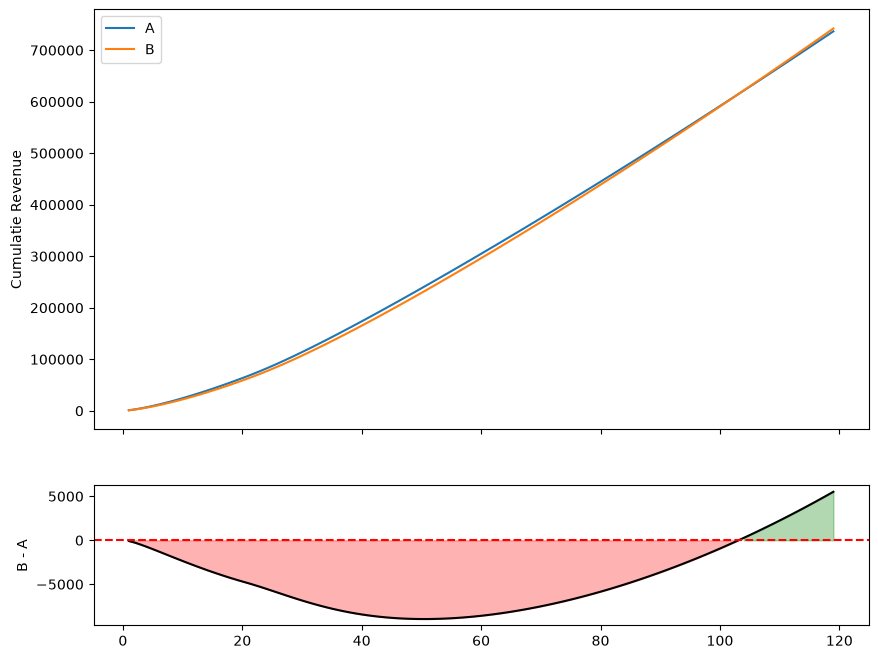

In [20]:
daily_sim["rev_diff_combined_cohort"] = daily_sim["cumulative_rev_b_combined_cohort"] - daily_sim["cumulative_rev_a_combined_cohort"]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Original Cumulative Rev
ax1.plot(daily_sim.index, daily_sim["cumulative_rev_a_combined_cohort"], label="A")
ax1.plot(daily_sim.index, daily_sim["cumulative_rev_b_combined_cohort"], label="B")
ax1.legend()
ax1.set_ylabel("Cumulatie Revenue")

# Difference
ax2.plot(daily_sim.index, daily_sim["rev_diff_combined_cohort"], color="black")
ax2.axhline(0, color="red", linestyle="--")
ax2.fill_between(
    daily_sim.index,
    daily_sim["rev_diff_combined_cohort"],
    0,
    where=daily_sim["rev_diff_combined_cohort"] > 0,
    alpha=0.3,
    color="green"
)
ax2.fill_between(
    daily_sim.index,
    daily_sim["rev_diff_combined_cohort"],
    0,
    where=daily_sim["rev_diff_combined_cohort"] < 0,
    alpha=0.3,
    color="red"
)

ax2.set_ylabel("B - A")

In [21]:
daily_sim.loc[30, ["cumulative_rev_a_sale", "cumulative_rev_b_sale", "cumulative_rev_a_combined_cohort", "cumulative_rev_b_combined_cohort"]]

cumulative_rev_a_sale               118597.82592
cumulative_rev_b_sale               112694.44032
cumulative_rev_a_combined_cohort    113908.12056
cumulative_rev_b_combined_cohort    107062.49034
Name: 30, dtype: float64

Still Variant A is the better one in terms of Day 30 Monetization.
### e) Which one should you prioritize, and why? If you could only make **one** of these improvements:
1. Run the temporary 10-day sale (from d)
2. Add the new, permanent user source (from e/f)


In [22]:
daily_sim.loc[30, ["cumulative_rev_a_sale", "cumulative_rev_b_sale", "cumulative_rev_a_combined_cohort", "cumulative_rev_b_combined_cohort"]]

cumulative_rev_a_sale               118597.82592
cumulative_rev_b_sale               112694.44032
cumulative_rev_a_combined_cohort    113908.12056
cumulative_rev_b_combined_cohort    107062.49034
Name: 30, dtype: float64

In [23]:
daily_sim.loc[90, ["cumulative_rev_a_sale", "cumulative_rev_b_sale", "cumulative_rev_a_combined_cohort", "cumulative_rev_b_combined_cohort"]]

cumulative_rev_a_sale               503419.73352
cumulative_rev_b_sale               507656.92968
cumulative_rev_a_combined_cohort    517348.07592
cumulative_rev_b_combined_cohort    513703.59462
Name: 90, dtype: float64

In [34]:
daily_sim.loc[14, ["variant_a_new_source_retention", "variant_b_new_source_retention"]]

variant_a_new_source_retention    0.121879
variant_b_new_source_retention    0.141717
Name: 14, dtype: float64

In [37]:
all_days.loc[14, ["predicted_retention_variant_a", "predicted_retention_variant_b"]]

predicted_retention_variant_a    0.090751
predicted_retention_variant_b    0.106138
Name: 14, dtype: float64

I would prefer the second way because for both variants have higher retention rate for the **new, permanent user source** and in the long run (with the assumption of constant monetization metrics) higher DAU means higher Revenue.

# Task 2
Using the data set provided to you, we want you to make analyses about the different
aspects of the users’ characteristics. For example, you can consider segmenting users
based on their first-day engagement.
Other options might be: Are there any trends in session duration over time? Do sessions
tend to get longer or shorter as time goes on?
We ask you to be more creative and conduct an analysis that uncovers such
segmentations or trends. You can use any tool to present and visualize your findings.

In [24]:
data_path = "./data/data_analyst_case_vertigo2025"

In [25]:
files_to_read = []
for file in listdir(data_path):
    files_to_read.append(path.join(data_path, file))
print(files_to_read)

['./data/data_analyst_case_vertigo2025/000000000006.csv.gz', './data/data_analyst_case_vertigo2025/000000000014.csv.gz', './data/data_analyst_case_vertigo2025/000000000016.csv.gz', './data/data_analyst_case_vertigo2025/000000000008.csv.gz', './data/data_analyst_case_vertigo2025/000000000004.csv.gz', './data/data_analyst_case_vertigo2025/.DS_Store', './data/data_analyst_case_vertigo2025/000000000000.csv.gz', './data/data_analyst_case_vertigo2025/000000000012.csv.gz', './data/data_analyst_case_vertigo2025/000000000010.csv.gz', './data/data_analyst_case_vertigo2025/000000000002.csv.gz', './data/data_analyst_case_vertigo2025/000000000007.csv.gz', './data/data_analyst_case_vertigo2025/000000000015.csv.gz', './data/data_analyst_case_vertigo2025/000000000009.csv.gz', './data/data_analyst_case_vertigo2025/000000000005.csv.gz', './data/data_analyst_case_vertigo2025/000000000001.csv.gz', './data/data_analyst_case_vertigo2025/000000000013.csv.gz', './data/data_analyst_case_vertigo2025/00000000001

In [26]:
df_list = []
for file_path in files_to_read:
    df_list.append(pd.read_csv(file_path, encoding="utf-8"))
df = pd.concat((df_list))
df["event_date"] = pd.to_datetime(df["event_date"])
df["install_date"] = pd.to_datetime(df["install_date"])
df = df.drop(["Unnamed: 0"], axis=1)  # Read csv includes a ghost column with all NaN values, it is dropped here

In [27]:
df

,user_id,event_date,platform,install_date,country,total_session_count,total_session_duration,match_start_count,match_end_count,victory_count,defeat_count,server_connection_error,iap_revenue,ad_revenue
0,95BEF5B2A45B8C99,2024-02-15,android,2024-02-12,Vietnam,1.0,70.616,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,E09661DEA6B80899,2024-02-15,android,2023-09-30,Malaysia,3.0,8460.742,18.0,0.0,0.0,0.0,0.0,0.000000,0.035987
2,E788F51085AE85B6,2024-02-15,android,2024-02-09,Ukraine,1.0,1.417,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,575BA25AD1E25D40,2024-02-15,android,2022-10-01,India,1.0,4.654,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,7EE7037F08FF528E,2024-02-15,ios,2022-01-03,Italy,1.0,298.785,2.0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429449,6850B19C4A0F450C,2024-03-15,android,2024-03-12,Brazil,4.0,35588.694,106.0,89.0,80.0,9.0,1.0,0.000000,0.127020
429450,D4294987846F3314,2024-03-15,android,2024-02-03,Malaysia,2.0,44854.927,103.0,94.0,64.0,30.0,1.0,0.000000,0.023950
429451,EA3CB2497615BFD5,2024-03-15,ios,2023-01-05,Türkiye,9.0,17740.473,101.0,96.0,96.0,0.0,0.0,0.000000,0.000000
429452,1551996F52C95473,2024-03-15,ios,2024-03-07,United Kingdom,4.0,31105.733,99.0,99.0,53.0,46.0,2.0,7.587676,0.066586
